# 01. 1차 DOE — SiO₂ 식각 프로파일 문제와 실험 설계

> **주의: 이 프로젝트의 모든 데이터는 물리 모델 기반 시뮬레이션으로 생성한 것이며,
> 실제 장비/팹 데이터가 아닙니다.** (교육 프로그램 팀 프로젝트를 개인 학습용으로 처음부터 재구현)

## 문제 배경

SiO₂ 플라즈마 식각 공정에서 두 가지 프로파일 불량이 동시에 발생하는 상황을 가정한다.

| 불량 | 현상 | 메커니즘 |
|---|---|---|
| **Undercut (U/T)** | 마스크 직하부 측벽이 횡방향으로 파임 | 측벽 보호막(passivation) 부족 시 방향성이 없는 F 라디칼이 등방성으로 측벽을 공격 |
| **Micro-trench (M/D)** | 트렌치 바닥 모서리가 중앙보다 깊게 파임 | 측벽에서 반사된 이온이 바닥 모서리에 집중되어 국부 식각률 상승 |

여기에 생산성 지표인 **Etch Rate(ER)** 와 측벽각 **θ**까지 총 4개 반응을 동시에 만족해야 한다.

## 인자와 목표

- **인자 3개**: CHF₃ 유량 20~30 sccm / Pressure 15~45 mTorr / Bias Power 75~105 W
- **목표**: ER ≥ 300 nm/min, U/T ≤ 2.0 %, M/D ≤ 3.0 %, θ → 90°

세 인자 모두 부족/과다 양쪽에서 서로 다른 불량을 유발하는 **trade-off 구조**이므로,
한 인자씩 바꾸는 방식(OFAT)이 아니라 **DOE 기반 다중 반응 최적화**가 필요하다.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import RANDOM_SEED, SECOND_DOE_CHF3, TRUE_COEF, SPECS
from src.data_gen import simulate_experiment, simulate_replicates
from src.doe_design import first_doe, second_doe
from src.analysis import (fit_all, fit_ols, ols_report, predict,
                          standardized_effects)
from src.optimization import (best_condition, desirability, grid_search,
                              validation_table)
from src.spc import monitoring_run, reproducibility_report
from src.visualization import (desirability_contour, effect_magnitude_plot,
                               i_chart_panel, main_effects_plot,
                               tradeoff_plot)

pd.set_option("display.width", 120)


## 1차 DOE 설계: 3인자 3수준 full factorial (3³ = 27 runs)

전 범위를 훑는 스크리닝 목적이므로 모든 수준 조합을 실험한다.
(1차 모델이 선형이므로 2수준으로도 충분하지만, 3수준을 쓰면 곡률 여부도 확인할 수 있다.)

In [2]:
design1 = first_doe()
design1.head(9)

,run,CHF3,P,B
0,1,20.0,15.0,75.0
1,2,20.0,15.0,90.0
2,3,20.0,15.0,105.0
3,4,20.0,30.0,75.0
4,5,20.0,30.0,90.0
5,6,20.0,30.0,105.0
6,7,20.0,45.0,75.0
7,8,20.0,45.0,90.0
8,9,20.0,45.0,105.0


## 가상 팹(virtual fab)에서 데이터 생성

`src/data_gen.py`의 ground-truth 선형 모델에 가우시안 노이즈를 더해 실험값을 만든다.
계수의 부호는 플라즈마 식각 물리를 반영한다:

- **CHF₃ ↑** → 폴리머 측벽 보호막 강화 → **U/T ↓**, F 라디칼 소모로 **ER ↓**
- **Pressure ↑** → 평균자유행로(MFP) 감소, 이온 산란 → **U/T ↑**, 모서리 집중 완화로 **M/D ↓**
- **Bias ↑** → 이온 에너지 증가 → **ER ↑**, 모서리 과식각으로 **M/D ↑**

In [3]:
doe1 = simulate_experiment(design1, seed=RANDOM_SEED)
doe1

,run,CHF3,P,B,ER,UT,MD,THETA
0,1,20.0,15.0,75.0,317.024,1.687,1.229,90.251
1,2,20.0,15.0,90.0,347.800,1.391,3.004,90.296
2,3,20.0,15.0,105.0,394.252,1.093,4.859,90.293
3,4,20.0,30.0,75.0,302.203,3.064,0.774,88.521
4,5,20.0,30.0,90.0,325.245,2.509,2.220,88.773
5,6,20.0,30.0,105.0,365.989,2.199,4.295,88.630
6,7,20.0,45.0,75.0,280.139,3.969,0.000,87.052
7,8,20.0,45.0,90.0,315.419,3.812,1.550,87.122
8,9,20.0,45.0,105.0,354.416,3.563,3.424,87.117
9,10,25.0,15.0,75.0,296.235,0.889,1.538,90.850


## Main Effect Plot

인자별 수준 평균을 보면 어떤 인자가 어떤 반응을 어느 방향으로 움직이는지 보인다.

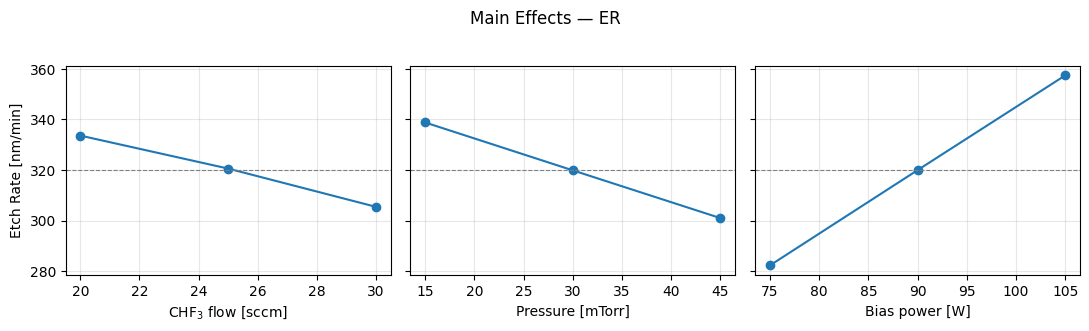

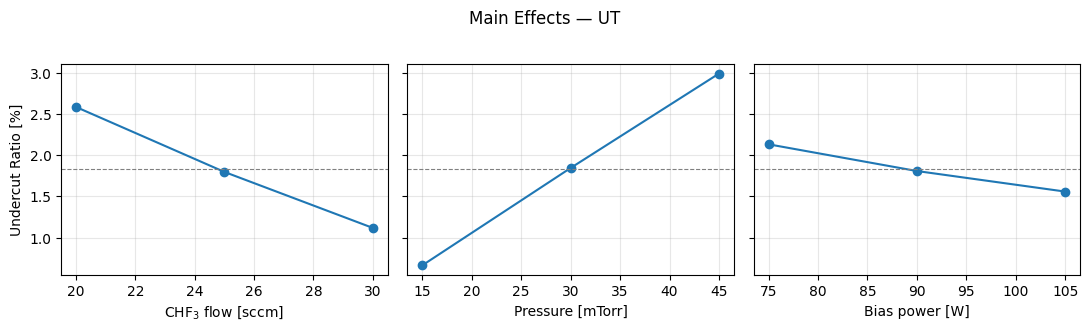

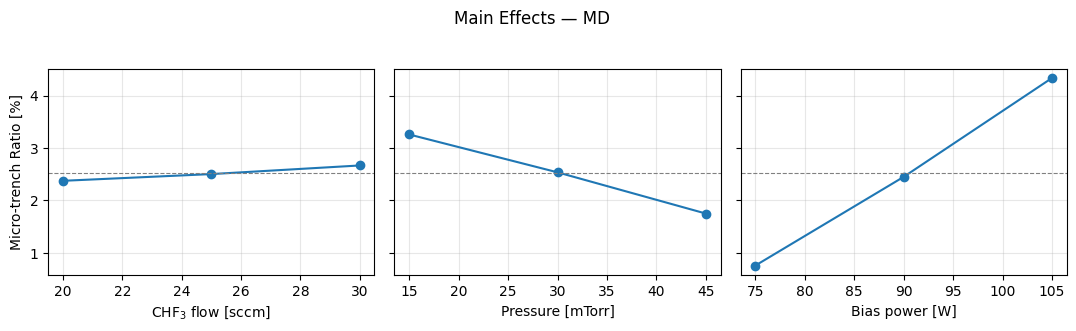

In [4]:
for r in ["ER", "UT", "MD"]:
    fig = main_effects_plot(doe1, r)
    plt.show()

## 표준화 효과 크기 — 어느 인자가 지배적인가

균형 잡힌 full factorial에서는 |최고수준 평균 − 최저수준 평균| 이 곧 효과 추정치다.

,ER,UT,MD
CHF3,28.175,1.470,0.293
P,37.870,2.331,1.509
B,75.231,0.575,3.580


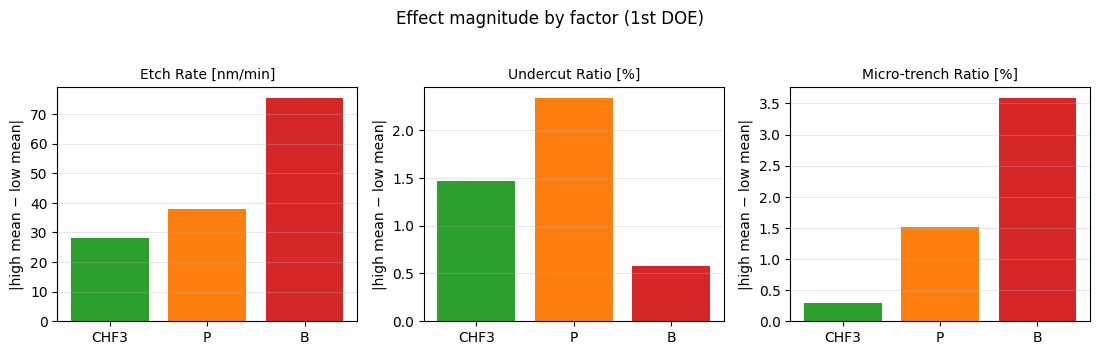

In [5]:
eff = standardized_effects(doe1, ["ER", "UT", "MD"])
display(eff.round(3))
fig = effect_magnitude_plot(eff)
plt.show()

## 1차 DOE 결론

| 반응 | 지배 인자 | 물리적 이유 |
|---|---|---|
| ER | **Bias** | 이온 타격 에너지를 직접 좌우 |
| M/D | **Bias** | 모서리 이온 집중도 결정 |
| U/T | **Pressure** | 이온 산란/라디칼 등방성 결정 |
| (전체) | CHF₃는 효과 최소 | 미세조정용 보조 인자 |

**핵심 발견**: M/D는 Bias를 *내려야* 좋아지고 ER은 Bias를 *올려야* 좋아진다 —
같은 인자에 상반된 요구가 걸리는 상충 구조. → **02 노트북에서 회귀 모델과 trade-off를 정량화한다.**